# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

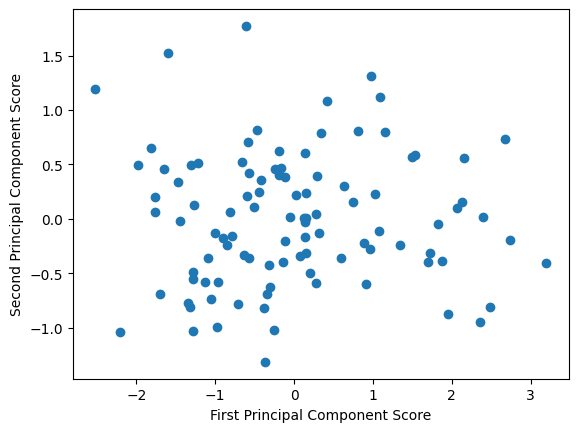

In [4]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The 3 outliers on the upper left indicate a lower first PCA score and a higher second PCA score. All 3 points are postively correlated. A lower PC1 scroes tells us that that the data points have a lower than average values in all 3 series but especially series3. In series 3, there's more noise and the outliers on the upper left should have a low series3 value. series1 and series2 are similar and their correlation is very high. They're basically indistinguishable in the PCA space. 

The graph effectively shows 3 correlated variables. It's great for spotting outliers in the joint distribution. 
The disadvantages are that there are no variables labels on the axes, no title, no colors or grouping etc. The reader would just see this blob of points. 
The most interesting poiints you can note here are that series1 and series2 are identical while series 3 has more noise. 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [5]:
df = pd.read_csv('US Commerce')

In [15]:
df.columns

Index(['Order Date', 'Row ID', 'Order ID', 'Ship Mode', 'Customer ID',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='str')

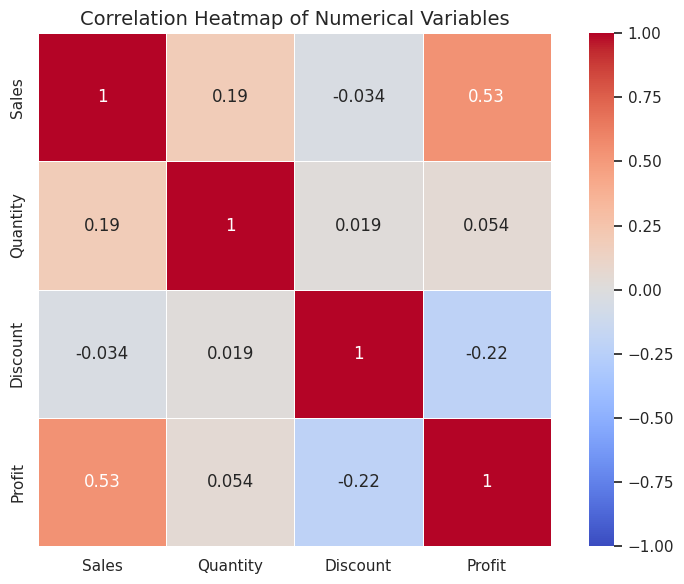

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("US Commerce")
df_num = df[['Sales', 'Quantity', 'Discount', 'Profit']]

plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

corr_matrix = df_num.corr()

# heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0, 
            linewidths=.5, square=True)

plt.title("Correlation Heatmap of Numerical Variables", fontsize=14)
plt.tight_layout()
plt.show()

Sales correlates positively with Profit, and Discount correlates negatively with Profit. This is something that we were already expecting!

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

I standardized the 4 numerical dimensions (Sales, Quantity, Discount, Profit) and applied PCA to find the directions of maximum variance.

In [ ]:
print("--- PCA Analysis ---")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

# initialize and fit PCA
pca = PCA()
pca.fit(X_scaled)

# explained variance
variance_ratio = pca.explained_variance_ratio_
cum_variance_ratio = np.cumsum(variance_ratio)

#variance captured by each principal component
for i, ratio in enumerate(variance_ratio):
    print(f"Principal Component {i+1}: captures {ratio*100:.2f}% of variance")
    
print(f"Cumulative Variance: {cum_variance_ratio}")

--- PCA Analysis ---
Principal Component 1: captures 40.69% of variance
Principal Component 2: captures 26.57% of variance
Principal Component 3: captures 22.16% of variance
Principal Component 4: captures 10.58% of variance
Cumulative Variance: [0.40694411 0.67265908 0.89424621 1.        ]


No you cannot represent the data using ol its projection onto the first principal component. Using only the first principal component (PC1) would capture just 40.69% of the total variance. Dropping down to a single dimension means you are throwing away roughly 60% of the mathematical information which wouldn't be effective. 

In [ ]:
def run_regression(target, features):
    X = df_num[features]
    y = df_num[target]
    
    #split the data into 80% training and 20% testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # initialize and train the model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    # R-squared score
    r2 = r2_score(y_test, preds)
    print(f"Predicting '{target}' using {features} -> R-squared: {r2:.4f}")

# combinations predicting 'Profit'
run_regression('Profit', ['Sales'])
run_regression('Profit', ['Discount'])
run_regression('Profit', ['Sales', 'Discount'])
run_regression('Profit', ['Sales', 'Discount', 'Quantity'])

# combinations predicting 'Sales'
run_regression('Sales', ['Quantity'])
run_regression('Sales', ['Profit'])

Predicting 'Profit' using ['Sales'] -> R-squared: 0.1936
Predicting 'Profit' using ['Discount'] -> R-squared: 0.0396
Predicting 'Profit' using ['Sales', 'Discount'] -> R-squared: 0.2309
Predicting 'Profit' using ['Sales', 'Discount', 'Quantity'] -> R-squared: 0.2307
Predicting 'Sales' using ['Quantity'] -> R-squared: 0.0184
Predicting 'Sales' using ['Profit'] -> R-squared: 0.1573


Notes:

- Sales combined with Discount are the most useful features for predicting Profit
- Only 23% of the variance in Profit can be explained by Sales, Discount, and Quantity
- Knowing how many items were bought doesn't help predict profit if you already know the total sales amount. It just adds unnecessary "noise" to the mathematical model. Someone buying 10 cheap pencils (Quantity=10, Sales=$5) generates far fewer sales dollars than someone buying 1 laptop (Quantity=1, Sales=$1,500). Quantity tells us almost nothing about total revenue.

The relatively poor linear regression performance proves that it is not highly usable for exact financial forecasting using simple linear models. We would need something more complex to handle discounting features. Our tests prove that you cannot accurately predict exact dollar profit using only Sales, Quantity, and Discounts.

As previously identified, the Sales and Profit categories are heavily skewed by extreme outliers (the "whales"). 11% of the total transactions are statistical outliers in the Sales column, representing massive corporate bulk orders (up to $14,000) that pull the variance far away from the median order size of $53.

If we combine the first two Principal Components (PC1 and PC2), we capture 67.26% of the total variance.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

I will be reproducing the Peka Break-Up Times plot. I tried my best the get the overall dips right. 

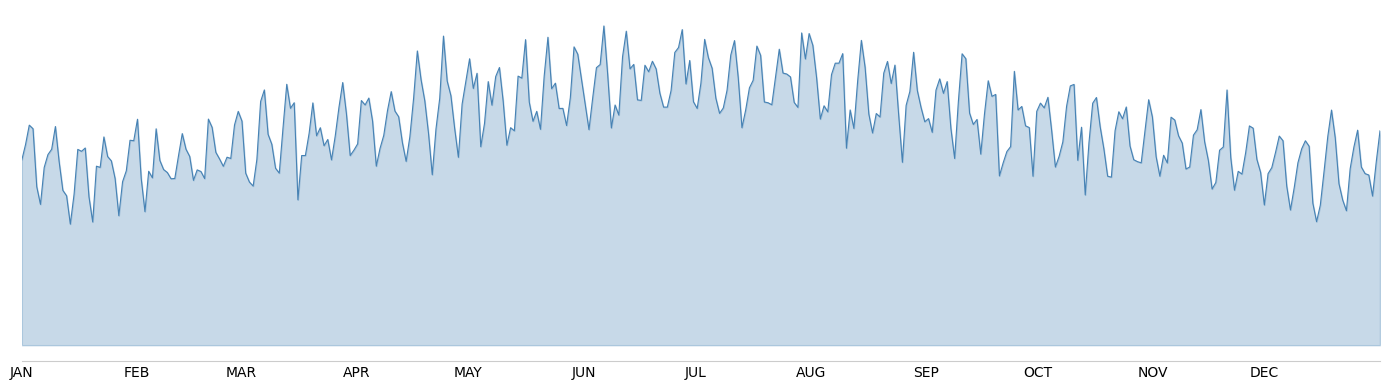

In [6]:
np.random.seed(42)

# ~365 days
days = np.linspace(0, 365, 365)

# signal with rough seasonal shape
base = (
    200
    + 40 * np.sin(2 * np.pi * days / 365 - np.pi / 2)          # broad seasonal curve
    + 30 * np.sin(2 * np.pi * days / 7)                          # weekly Monday spikes
    + 15 * np.random.randn(365)                                   # noise
)


base = np.clip(base, 80, None)

fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(days, base, alpha=0.3, color='steelblue')
ax.plot(days, base, color='steelblue', linewidth=0.8)

# X-axis: month labels
month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_labels = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=10)

ax.set_xlim(0, 365)
ax.yaxis.set_visible(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.show()